**Normalization and Standardization**

- In every dataset we have different columns has different units
- In every dataset we have different columns has values varies from -inf to +infinite
- It is very important standardize the data, make sure all the column values under smae range
- To achieve this we have two methods
    - Normalization
    - Standardization

**Normalization**
- Min Max scalar

**Standardization**
- Z-score

In [35]:
import pandas as pd                                                         # 54 th continue from prevoius notebook
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
file_path="C:\\DS_Py\\Visadataset.csv"            
visa_df=pd.read_csv(file_path)
visa_df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
# step-1: calculate min value of p_wage= min_wage
# step-2: calculate max value of p_wage=max_wage
# step-3: Dr=max_wage-min_wage
# step-4: Nr= p_wage-min_wage
# step-5: Nr/Dr

min_wage=visa_df['prevailing_wage'].min()
max_wage=visa_df['prevailing_wage'].max()
dr=max_wage-min_wage
nr=visa_df['prevailing_wage']-min_wage
visa_df['prevailing_wage_norm']=nr/dr

In [7]:
visa_df[['prevailing_wage','prevailing_wage_norm']]

,prevailing_wage,prevailing_wage_norm
0,592.2029,0.001849
1,83425.6500,0.261345
2,122996.8600,0.385312
3,83434.0300,0.261371
4,149907.3900,0.469616
...,...,...
25475,77092.5700,0.241505
25476,279174.7900,0.874579
25477,146298.8500,0.458311
25478,86154.7700,0.269895


In [8]:
visa_df['prevailing_wage_norm'].min(),visa_df['prevailing_wage_norm'].max()

(0.0, 1.0)

In [10]:
visa_df['prevailing_wage'].min(),visa_df['prevailing_wage'].max()     # see both output 2.13 converted 0  & 319210  converted 1

(2.1367, 319210.27)

In [12]:
min_id=visa_df['prevailing_wage_norm'].idxmin()
max_id=visa_df['prevailing_wage_norm'].idxmax()
min_id,max_id

(20575, 21077)

In [14]:
visa_df[['prevailing_wage','prevailing_wage_norm']].iloc[[min_id,max_id]]

,prevailing_wage,prevailing_wage_norm
20575,2.1367,0.0
21077,319210.2700,1.0


**Min Max scalar**

- minmaxscala is a method from sklearn preprocessing
- Read the packages
- Save the packages
- Apply fit transform

In [21]:
#################### read ###########
file_path="C:\\DS_Py\\Visadataset.csv"
visa_df=pd.read_csv(file_path)

# step-1:
from sklearn.preprocessing import MinMaxScaler

# step-2:
mms=MinMaxScaler()

#step-3:
visa_df['prevailing_wage_norm']=mms.fit_transform(visa_df[['prevailing_wage']])

In [23]:
visa_df[['prevailing_wage_norm','prevailing_wage']]

,prevailing_wage_norm,prevailing_wage
0,0.001849,592.2029
1,0.261345,83425.6500
2,0.385312,122996.8600
3,0.261371,83434.0300
4,0.469616,149907.3900
...,...,...
25475,0.241505,77092.5700
25476,0.874579,279174.7900
25477,0.458311,146298.8500
25478,0.269895,86154.7700


**Note**:

    Inside MinMaxScalar pass dataframe not series

In [20]:
# array                   # how many brackets will give that much dimensional array [[sd]] == 2D array
V1=np.array([[[1,2,3,4]]])
V1.ndim

3

**Z-score**

In [31]:
mean=visa_df['prevailing_wage'].mean()
std=visa_df['prevailing_wage'].std()
Nr=visa_df['prevailing_wage']-mean
visa_df['prevailing_wage_Zscore']=Nr/std


In [32]:
visa_df[['prevailing_wage','prevailing_wage_Zscore']]

,prevailing_wage,prevailing_wage_Zscore
0,592.2029,-1.398510
1,83425.6500,0.169832
2,122996.8600,0.919060
3,83434.0300,0.169991
4,149907.3900,1.428576
...,...,...
25475,77092.5700,0.049923
25476,279174.7900,3.876083
25477,146298.8500,1.360253
25478,86154.7700,0.221504


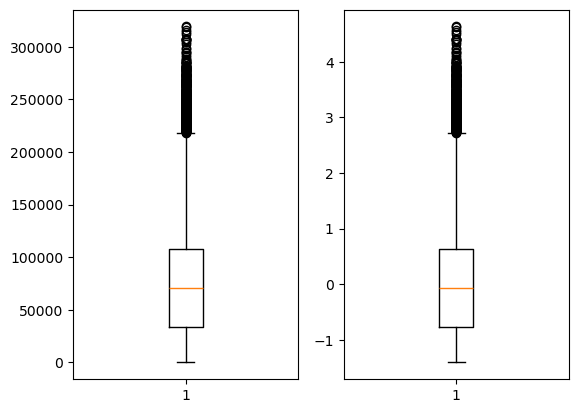

In [38]:
plt.subplot(1,2,1)
plt.boxplot(visa_df['prevailing_wage'])
plt.subplot(1,2,2)
plt.boxplot(visa_df['prevailing_wage_Zscore'])
plt.show()

**StandardScalar**


In [45]:
######### read data  ######333
file_path="C:\\DS_Py\\Visadataset.csv"            
visa_df=pd.read_csv(file_path)

# step-1: import
from sklearn.preprocessing import StandardScaler

# step-2: save package
ss=StandardScaler()

# step-3: fit_transfrom
visa_df['prevailing_wage_ss']=ss.fit_transform(visa_df[['prevailing_wage']])
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_ss
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398537
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169835
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919079
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169994
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428604
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049924
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876159
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360280
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221509


In [44]:
visa_df[['prevailing_wage_ss','prevailing_wage']]

,prevailing_wage_ss,prevailing_wage
0,-1.398537,592.2029
1,0.169835,83425.6500
2,0.919079,122996.8600
3,0.169994,83434.0300
4,1.428604,149907.3900
...,...,...
25475,0.049924,77092.5700
25476,3.876159,279174.7900
25477,1.360280,146298.8500
25478,0.221509,86154.7700


**outlayer analysis**

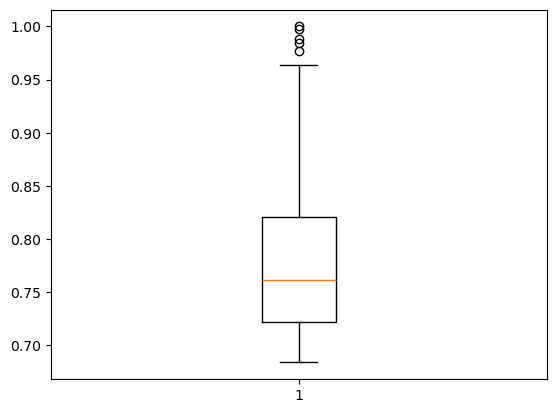

In [71]:
# this graph for only for outlier analysis

file_path="C:\\DS_Py\\Visadataset.csv"
visa_df=pd.read_csv(file_path)

# step-1:
from sklearn.preprocessing import MinMaxScaler

# step-2:
mms=MinMaxScaler()

#step-3:
visa_df['prevailing_wage_norm']=mms.fit_transform(visa_df[['prevailing_wage']])

# outlaiers of the prevaling_wage_norm

q1=np.quantile(visa_df['prevailing_wage_norm'],0.25)
q2=np.quantile(visa_df['prevailing_wage_norm'],0.50)
q3=np.quantile(visa_df['prevailing_wage_norm'],0.75)

IQR=q3-q1

ub=q3+1.5*IQR
lb=q1-1.5*IQR

con1=visa_df['prevailing_wage_norm']>ub
con2=visa_df['prevailing_wage_norm']<lb

con=con1|con2

outliers=visa_df[con]
outliers

plt.boxplot(outliers['prevailing_wage_norm'])
plt.show()

**non outlaiers analysis**

0.6839218734593564
-0.23986451929794855


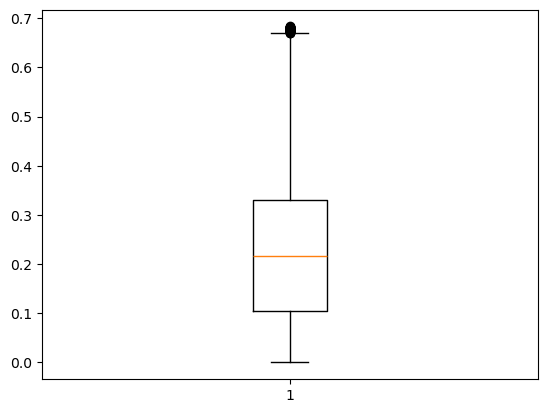

In [75]:

# this graph for only for outlier analysis

file_path="C:\\DS_Py\\Visadataset.csv"
visa_df=pd.read_csv(file_path)

# step-1:
from sklearn.preprocessing import MinMaxScaler

# step-2:
mms=MinMaxScaler()

#step-3:
visa_df['prevailing_wage_norm']=mms.fit_transform(visa_df[['prevailing_wage']])

# non_outlaiers of the prevaling_wage_norm

q1=np.quantile(visa_df['prevailing_wage_norm'],0.25)
q2=np.quantile(visa_df['prevailing_wage_norm'],0.50)
q3=np.quantile(visa_df['prevailing_wage_norm'],0.75)

IQR=q3-q1

ub=q3+1.5*IQR
lb=q1-1.5*IQR
print(ub)
print(lb)
con1=visa_df['prevailing_wage_norm']<ub              # change > to <
con2=visa_df['prevailing_wage_norm']>lb              # change < to >

con=con1&con2                                       # change | to &

non_outliers=visa_df[con]
non_outliers

plt.boxplot(non_outliers['prevailing_wage_norm'])
plt.show()

**outlayer analysis using Zscore**

427


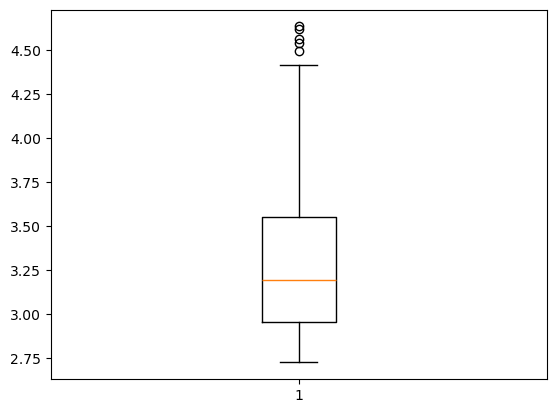

In [81]:
mean=visa_df['prevailing_wage'].mean()
std=visa_df['prevailing_wage'].std()
Nr=visa_df['prevailing_wage']-mean
visa_df['prevailing_wage_Zscore']=Nr/std

# outlaiers of the prevaling_wage_Zscore

q1=np.quantile(visa_df['prevailing_wage_Zscore'],0.25)
q2=np.quantile(visa_df['prevailing_wage_Zscore'],0.50)
q3=np.quantile(visa_df['prevailing_wage_Zscore'],0.75)

IQR=q3-q1

ub=q3+1.5*IQR
lb=q1-1.5*IQR

con1=visa_df['prevailing_wage_Zscore']>ub
con2=visa_df['prevailing_wage_Zscore']<lb

con=con1|con2

Zoutliers=visa_df[con]
print(len(Zoutliers))

plt.boxplot(Zoutliers['prevailing_wage_Zscore'])
plt.show()

2.723793997039226
-2.8593711801531247
25053


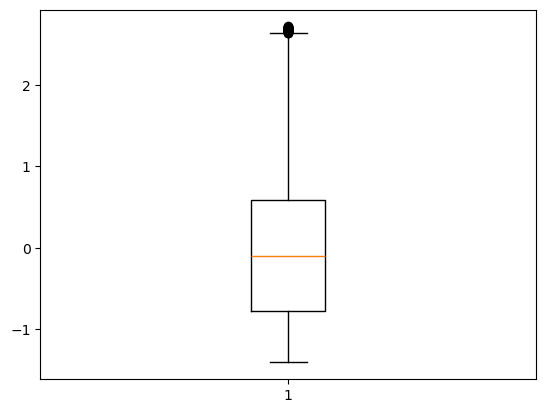

In [84]:
# non_outlaiers of the prevaling_wage_Zscore
mean=visa_df['prevailing_wage'].mean()
std=visa_df['prevailing_wage'].std()
Nr=visa_df['prevailing_wage']-mean
visa_df['prevailing_wage_Zscore']=Nr/std

q1=np.quantile(visa_df['prevailing_wage_Zscore'],0.25)
q2=np.quantile(visa_df['prevailing_wage_Zscore'],0.50)
q3=np.quantile(visa_df['prevailing_wage_Zscore'],0.75)

IQR=q3-q1

ub=q3+1.5*IQR
lb=q1-1.5*IQR
print(ub)
print(lb)
con1=visa_df['prevailing_wage_Zscore']<ub              # change > to <
con2=visa_df['prevailing_wage_Zscore']>lb              # change < to >

con=con1&con2                                       # change | to &

non_outliers=visa_df[con]
print(len(non_outliers))

plt.boxplot(non_outliers['prevailing_wage_Zscore'])
plt.show()